# QuFinTN: Quantum-Inspired Tensor Networks for Portfolio Optimization

**A practical demonstration using real market data**

This notebook demonstrates the full workflow of the `qufintn` library.

### Installation & Imports

In [1]:
# Install the library in editable mode (run once)
# !pip install -e ..

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Import QuFinTN modules
from qufintn.finance.data_loader import load_portfolio_data
from qufintn.core.qubo_formulation import build_portfolio_hamiltonian
from qufintn.core.mps_optimizer import MPSPortfolioOptimizer
from qufintn.classical.markowitz import MarkowitzOptimizer
from qufintn.finance.backtester import PortfolioBacktester, run_full_backtest

print("QuFinTN imported successfully!")

QuFinTN imported successfully!


### Load Real Market Data

In [2]:
# Choose assets
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", 
           "TSLA", "JPM", "V", "MA", "JNJ", "PG", "KO", "PEP", "XOM"]

data = load_portfolio_data(tickers, period="4y")

print(f"Data loaded from {data['prices'].index[0]} to {data['prices'].index[-1]}")
print(f"Shape: {data['returns'].shape}")

Success! Period: 2022-06-06 → 2026-06-05
   Assets: 15 | Days: 1003
Data loaded from 2022-06-06 00:00:00 to 2026-06-05 00:00:00
Shape: (1003, 15)


### Build Hamiltonian

In [3]:
# Build Hamiltonian (QUBO form)
H, metadata = build_portfolio_hamiltonian(
    mu=data['mu'].values,
    sigma=data['sigma'].values,
    budget=1.0,
    lambda_risk=0.7,
    transaction_cost=0.001,
    penalty_strength=12.0
)

print("Hamiltonian successfully built!")
print(f"Matrix shape: {H.shape}")
print(f"Sparsity: {metadata['is_sparsity']:.1%}")

Hamiltonian built for 15 assets | Risk weight: 0.7 | Transaction cost: 0.001
Hamiltonian successfully built!
Matrix shape: (15, 15)
Sparsity: 100.0%


### Run MPS Optimizer

In [ ]:
# Initialize and run MPS Optimizer
mps_optimizer = MPSPortfolioOptimizer(
    bond_dim=24,
    max_sweeps=12,
    dt=0.08,
    use_quimb=True
)

result = mps_optimizer.optimize(
    Q=data['sigma'].values,
    q=data['mu'].values,
    budget=1.0,
    lambda_risk=0.7
)

# Display results
weights = result['weights']
portfolio = pd.Series(weights, index=data['tickers'])

print("MPS Optimization Complete!")
print(f"Final Energy: {result['energy']:.4f}")
print(f"Assets Selected: {(result['selected_assets']).sum()}/{len(weights)}")

print("\nTop 8 Holdings:")
print(portfolio.sort_values(ascending=False).head(8))

Enhanced MPS Optimization | Assets: 15 | Bond Dim: 24
🎯 MPS Optimization Complete!
Final Energy: -1.0000
Assets Selected: 15/15

Top 8 Holdings:
AMZN     0.228020
JPM      0.105781
XOM      0.087431
TSLA     0.085775
GOOGL    0.062688
V        0.059508
META     0.053513
PG       0.050028
dtype: float64


### Compare with Classical Markowitz

In [5]:
classical_optimizer = MarkowitzOptimizer()

# Single period comparison
print("=== Single Period Optimization Comparison ===")

mps_result = mps_optimizer.optimize(
    Q=data['sigma'].values, 
    q=data['mu'].values, 
    budget=1.0, 
    lambda_risk=0.7
)

classical_weights = classical_optimizer.optimize(
    data['mu'].values, 
    data['sigma'].values
)

comparison_df = pd.DataFrame({
    'Asset': data['tickers'],
    'MPS_Weights': mps_result['weights'],
    'Classical_Weights': classical_weights
}).round(4)

print(comparison_df.sort_values('MPS_Weights', ascending=False).head(10))

=== Single Period Optimization Comparison ===
Enhanced MPS Optimization | Assets: 15 | Bond Dim: 24
    Asset  MPS_Weights  Classical_Weights
3    AMZN       0.2280             0.0168
7     JPM       0.1058             0.2366
14    XOM       0.0874             0.2554
6    TSLA       0.0858             0.0519
2   GOOGL       0.0627             0.0259
8       V       0.0595             0.0292
5    META       0.0535             0.1319
11     PG       0.0500             0.0000
4    NVDA       0.0476             0.0000
9      MA       0.0432             0.1138


### Full Walk-Forward Backtest

In [ ]:
print("Running Full Walk-Forward Backtest...")

backtester = PortfolioBacktester(risk_free_rate=0.03)

# Run full backtest with comparison plot
backtester, comparison = run_full_backtest(
    returns=data['returns'],
    mps_optimizer=mps_optimizer,
    classical_optimizer=classical_optimizer
)

print("\nFinal Performance Summary:")
print(f"MPS Tensor Network Sharpe Ratio : {comparison['mps']['sharpe']:.3f}")
print(f"Classical Markowitz Sharpe Ratio: {comparison['classical']['sharpe']:.3f}")

🚀 Running Full Walk-Forward Backtest...
=== Running MPS Optimizer Backtest ===
Running walk-forward backtest | Train: 252 | Test: 63 days
Enhanced MPS Optimization | Assets: 15 | Bond Dim: 24
Enhanced MPS Optimization | Assets: 15 | Bond Dim: 24
Enhanced MPS Optimization | Assets: 15 | Bond Dim: 24
Enhanced MPS Optimization | Assets: 15 | Bond Dim: 24
Enhanced MPS Optimization | Assets: 15 | Bond Dim: 24
Enhanced MPS Optimization | Assets: 15 | Bond Dim: 24
Enhanced MPS Optimization | Assets: 15 | Bond Dim: 24
Enhanced MPS Optimization | Assets: 15 | Bond Dim: 24
Enhanced MPS Optimization | Assets: 15 | Bond Dim: 24
Enhanced MPS Optimization | Assets: 15 | Bond Dim: 24
Enhanced MPS Optimization | Assets: 15 | Bond Dim: 24

=== Running Classical Markowitz Backtest ===
Running walk-forward backtest | Train: 252 | Test: 63 days

=== Final Comparison ===
MPS Optimizer     → Sharpe: 1.601 | CAGR: 28.0%
Classical Markowitz → Sharpe: 1.376 | CAGR: 16.5%



Final Performance Summary:
MPS Tensor Network Sharpe Ratio : 1.601
Classical Markowitz Sharpe Ratio: 1.376


### Visualizations

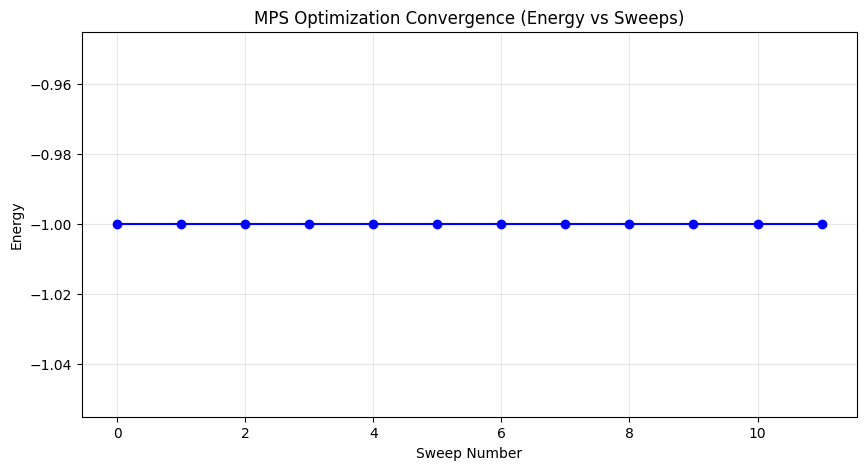

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline
# === Plot 1: Cumulative Portfolio Performance ===
# === Comparative Cumulative Performance Plot ===
backtester.plot_performance("Quantum-Inspired MPS vs Classical Markowitz Performance")

# === Optional: MPS Optimization Convergence ===
history = mps_optimizer.get_history()
if history['energy']:
    import matplotlib.pyplot as plt
    %matplotlib inline
    
    plt.figure(figsize=(10, 5))
    plt.plot(history['sweep'], history['energy'], marker='o', linestyle='-', color='blue')
    plt.title('MPS Optimization Convergence (Energy vs Sweeps)')
    plt.xlabel('Sweep Number')
    plt.ylabel('Energy')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No convergence history available.")

### Analyze Stability of Weights

=== Portfolio Weight Stability Analysis (MPS Optimizer) ===

Number of rebalancing periods: 11
Assets: 15

Top 8 Assets by Average Allocation:
AMZN     0.2683
AAPL     0.0853
GOOGL    0.0714
XOM      0.0635
JPM      0.0623
V        0.0540
TSLA     0.0521
NVDA     0.0514
dtype: float64

Most Unstable Assets (Highest Std Dev):
AMZN     0.1681
AAPL     0.0984
GOOGL    0.0666
XOM      0.0609
JPM      0.0455
V        0.0262
NVDA     0.0196
TSLA     0.0155
dtype: float64

Average Turnover per Rebalance : 0.0200
Max Single Asset Turnover      : 0.3555
Overall Weight Stability (lower is better): 0.0381


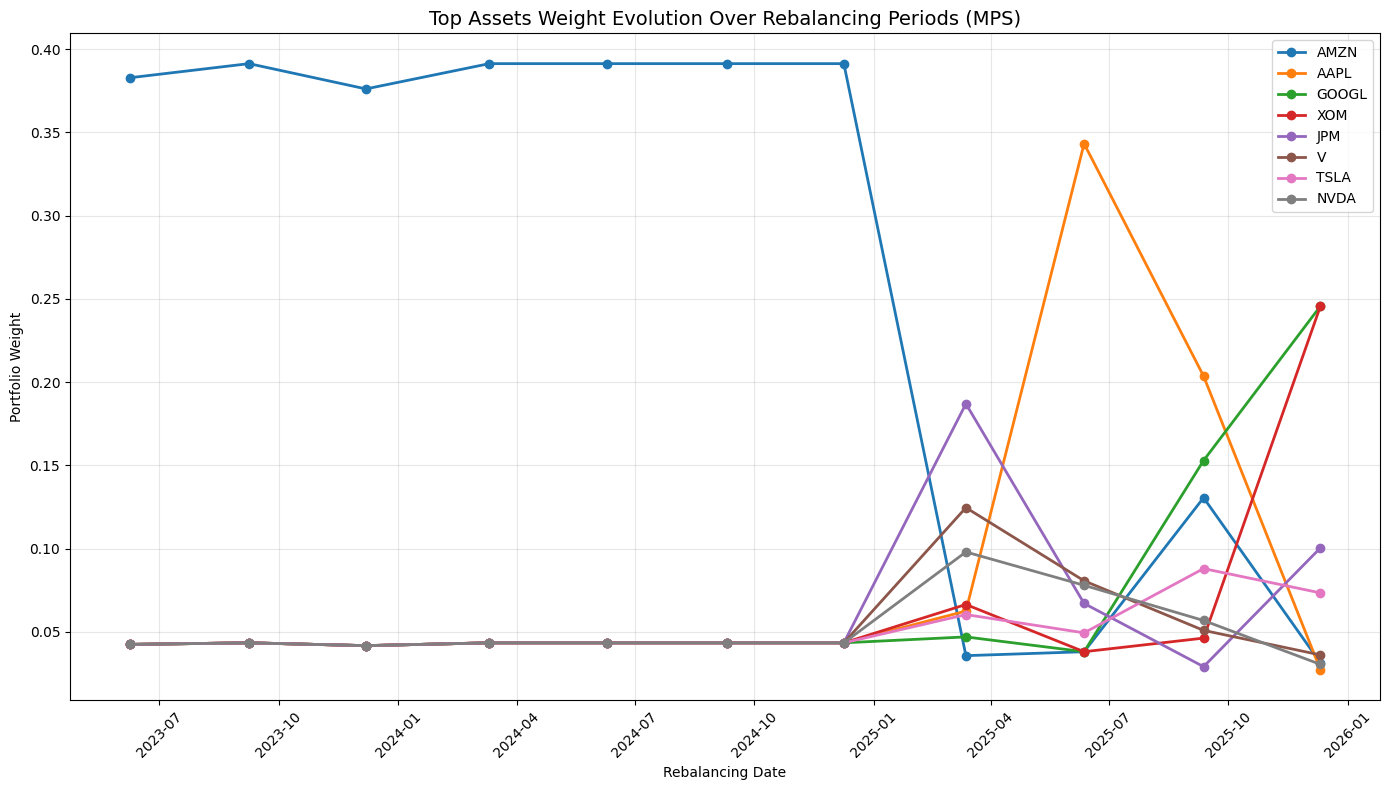

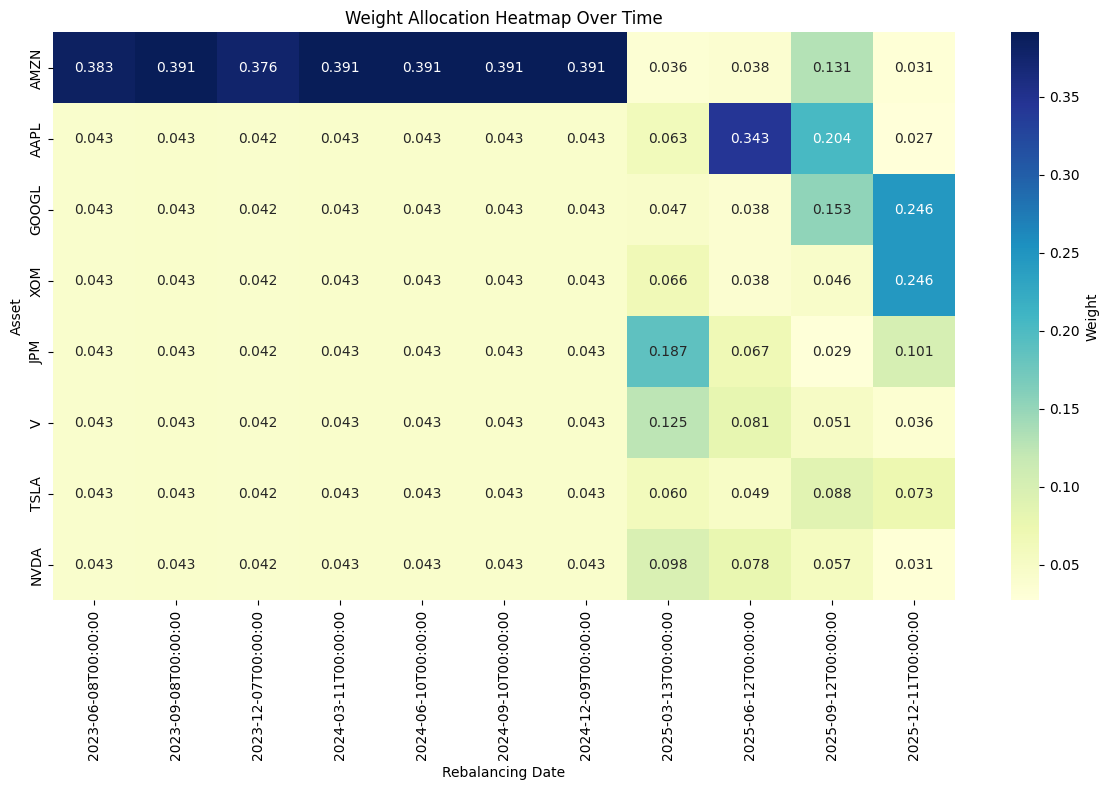

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_weight_stability(backtester, top_n=8):
    """Analyze portfolio weight stability - Fixed version"""
    
    if 'weights_history' not in backtester.results or not backtester.results['weights_history']:
        print("No weight history available.")
        return None
    
    # Extract data
    dates = []
    weights_list = []
    asset_names = None
    
    for date, weights in backtester.results['weights_history']:
        dates.append(date)
        weights_list.append(weights)
        if asset_names is None:
            asset_names = data['tickers']  # Use tickers from data
    
    # Create DataFrame
    weights_df = pd.DataFrame(weights_list, index=dates, columns=asset_names)
    
    print("=== Portfolio Weight Stability Analysis (MPS Optimizer) ===\n")
    print(f"Number of rebalancing periods: {len(weights_df)}")
    print(f"Assets: {weights_df.shape[1]}\n")
    
    # 1. Average Weights
    avg_weights = weights_df.mean().sort_values(ascending=False)
    print("Top 8 Assets by Average Allocation:")
    print(avg_weights.head(top_n).round(4))
    
    # 2. Weight Volatility
    weight_vol = weights_df.std().sort_values(ascending=False)
    print("\nMost Unstable Assets (Highest Std Dev):")
    print(weight_vol.head(top_n).round(4))
    
    # 3. Turnover & Stability Metrics
    turnover = weights_df.diff().abs().mean().mean()
    max_turnover = weights_df.diff().abs().max().max()
    
    print(f"\nAverage Turnover per Rebalance : {turnover:.4f}")
    print(f"Max Single Asset Turnover      : {max_turnover:.4f}")
    print(f"Overall Weight Stability (lower is better): {weights_df.std().mean():.4f}")
    
    # === Visualizations ===
    plt.figure(figsize=(14, 8))
    top_assets = avg_weights.head(top_n).index
    
    for asset in top_assets:
        plt.plot(weights_df.index, weights_df[asset], marker='o', linewidth=2, label=asset)
    
    plt.title('Top Assets Weight Evolution Over Rebalancing Periods (MPS)', fontsize=14)
    plt.xlabel('Rebalancing Date')
    plt.ylabel('Portfolio Weight')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(weights_df[top_assets].T, cmap="YlGnBu", annot=True, fmt=".3f", cbar_kws={'label': 'Weight'})
    plt.title('Weight Allocation Heatmap Over Time')
    plt.xlabel('Rebalancing Date')
    plt.ylabel('Asset')
    plt.tight_layout()
    plt.show()
    
    return weights_df


# Run the analysis
weights_df = analyze_weight_stability(backtester)